# 🛒 E-Commerce Income Segmentation — Analysis
**Dataset:** 6 relational tables · ~133K rows · 51 columns · 3.5 years (2023–2026)  
**Author:** Holarbrain | [holarbrain.github.io](https://holarbrain.github.io)  
**Stack:** Python · pandas · matplotlib · seaborn

---


### 1. Load Datasets
First, we'll load the relevant CSV files into pandas DataFrames.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load datasets with confirmed paths
users = pd.read_csv('/content/users.csv')
purchases = pd.read_csv('/content/purchases.csv')
reviews = pd.read_csv('/content/reviews.csv')
products = pd.read_csv('/content/products.csv')

# Quick look at the data
display(users.head(2))
display(purchases.head(2))

,user_id,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier
0,8826d916-cdfb-41c6-81ff-91a761565a70,18,Female,US,Changchester,2026-02-05,medium,Sports & Outdoors,bronze
1,2416da6e-c212-4ddb-8d88-00160eb686b2,32,Female,AU,New Tammyfort,2025-03-03,very_high,Automotive,bronze


,purchase_id,order_id,user_id,product_id,session_id,interaction_id,quantity,unit_price,total_amount,order_date
0,6a57a9c2-5d12-441f-8bde-2781458c6da7,b5d39dff-18ce-4032-8d8d-02db73e5c09e,d669cbc4-2606-49ef-b643-b902b1f0b196,af3bccbc-763f-4162-a178-bf20bfaeccba,003fc1af-ae18-4436-acd7-e4936459c620,ce36fbcb-a957-4388-8717-b8cf3041685a,2,5.74,11.48,2023-01-15 18:05:44.055402424
1,4d758486-b0bd-41d5-84cc-921d01ec3a6a,924f67e7-aac8-49bd-abc7-19339a24fb85,dfd9ccd9-9288-45cd-a1cf-f9c08e2a1b37,0c70a612-d55e-4879-9bce-299d323437f3,6106d434-cac5-40b3-b2a5-0d88a989ed26,9e36d37a-f610-483a-88e0-33b14973265f,2,79.42,158.84,2023-01-19 18:02:11.094635944


### 2. Feature Engineering for Segmentation
We need to aggregate data at the user level to find features like total spend, frequency of purchase, and average review score.

In [7]:
# 2. Re-run Feature Engineering
if 'price' not in purchases.columns:
    purchases = purchases.merge(products[['product_id', 'price']], on='product_id', how='left')

user_purchases = purchases.groupby('user_id').agg(
    total_spend=('price', 'sum'),
    purchase_count=('purchase_id', 'count')
).reset_index()

user_reviews = reviews.groupby('user_id').agg(
    avg_rating=('rating', 'mean')
).reset_index()

segment_df = users[['user_id']].merge(user_purchases, on='user_id', how='left')
segment_df = segment_df.merge(user_reviews, on='user_id', how='left')

segment_df[['total_spend', 'purchase_count']] = segment_df[['total_spend', 'purchase_count']].fillna(0)
segment_df['avg_rating'] = segment_df['avg_rating'].fillna(segment_df['avg_rating'].mean())

display(segment_df.head())

,user_id,total_spend,purchase_count,avg_rating
0,8826d916-cdfb-41c6-81ff-91a761565a70,74.49,1.0,5.000000
1,2416da6e-c212-4ddb-8d88-00160eb686b2,0.00,0.0,4.080712
2,eb819333-b501-4c18-8c53-c786ed62c2f9,22.98,1.0,5.000000
3,71445abc-2f0d-4ac2-8097-acb7a3823bc9,0.00,0.0,4.080712
4,13d16283-160e-4c20-aebd-f9d6297e4c73,0.00,0.0,4.080712


### 3. Clustering
We will scale the features and apply K-Means clustering.

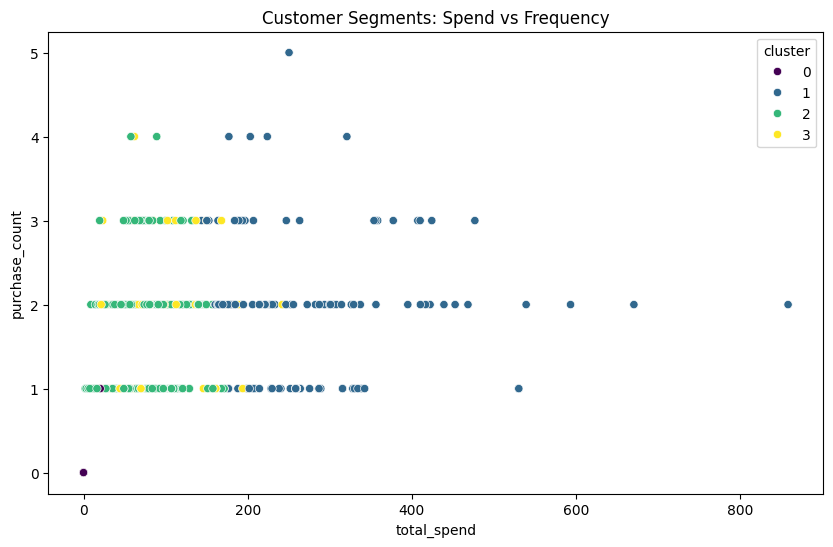

In [8]:
# 3. Re-run Clustering
features = ['total_spend', 'purchase_count', 'avg_rating']
x = segment_df[features]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
segment_df['cluster'] = kmeans.fit_predict(x_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=segment_df, x='total_spend', y='purchase_count', hue='cluster', palette='viridis')
plt.title('Customer Segments: Spend vs Frequency')
plt.show()

### 4. Segment Summary
Let's look at the average characteristics of each segment.

In [9]:
# 4. Re-run Summary
summary = segment_df.groupby('cluster')[features].mean().reset_index()
display(summary)

,cluster,total_spend,purchase_count,avg_rating
0,0,0.002341,0.000115,4.086752
1,1,277.030426,1.815603,4.342195
2,2,56.019139,1.268863,4.418793
3,3,54.188745,1.238095,2.316739


### 5. Income Level Analysis across Segments
We'll now join the user income information to our segments to see how it varies.

### 6. Age Distribution across Segments
Let's analyze the age distribution within each identified cluster.

,cluster,age
0,0,36.464257
1,1,37.326241
2,2,36.629118
3,3,36.528139


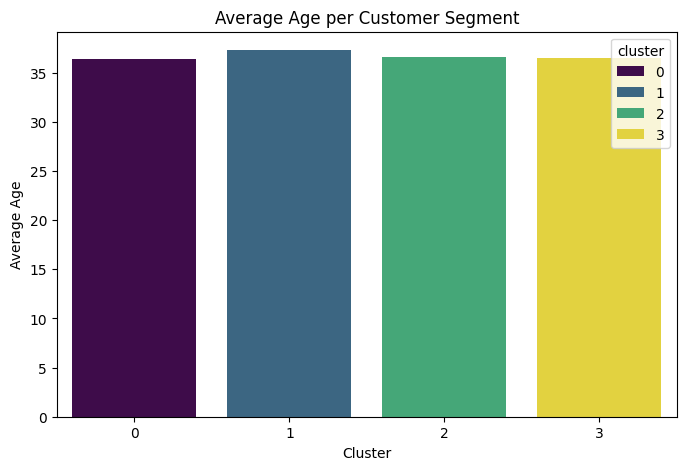

In [10]:
if 'age' not in segment_df.columns:
    segment_df = segment_df.merge(users[['user_id', 'age']], on='user_id', how='left')

# Calculate average age per cluster
age_summary = segment_df.groupby('cluster')['age'].mean().reset_index()
display(age_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=age_summary, x='cluster', y='age', hue='cluster', palette='viridis')
plt.title('Average Age per Customer Segment')
plt.xlabel('Cluster')
plt.ylabel('Average Age')
plt.show()

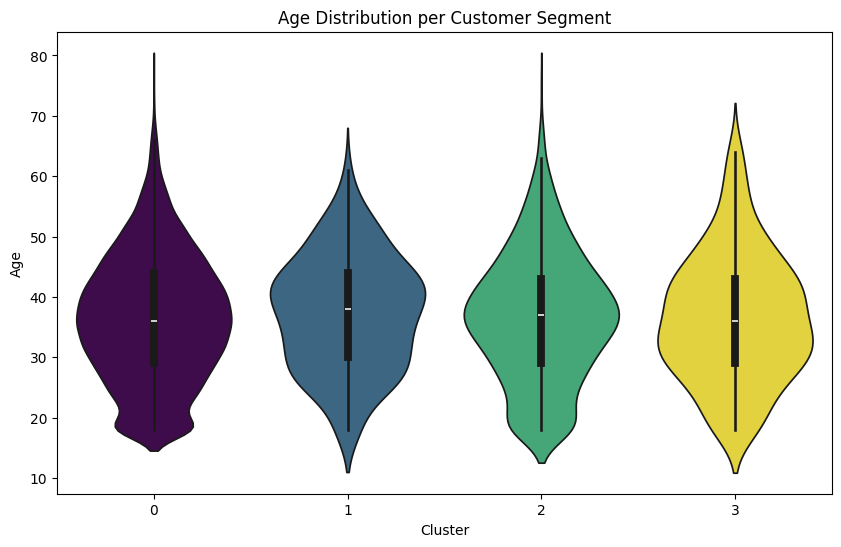

In [11]:
# Visualize age distribution with violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=segment_df, x='cluster', y='age', hue='cluster', palette='viridis', legend=False)
plt.title('Age Distribution per Customer Segment')
plt.xlabel('Cluster')
plt.ylabel('Age')
plt.show()

### 7. Summary of Customer Segments

In [13]:
# Ensure income_summary is defined before the loop
if 'income_level' not in segment_df.columns:
    segment_df = segment_df.merge(users[['user_id', 'income_level']], on='user_id', how='left')

income_map = {'low': 1, 'medium': 2, 'high': 3}
segment_df['income_numeric'] = segment_df['income_level'].map(income_map)
income_summary = segment_df.groupby('cluster')['income_numeric'].mean().reset_index()

for i in range(len(summary)):
    cluster_id = summary.loc[i, 'cluster']
    total_spend = summary.loc[i, 'total_spend']
    purchase_count = summary.loc[i, 'purchase_count']
    avg_rating = summary.loc[i, 'avg_rating']

    # Get income level (convert numeric back to categorical for better readability)
    income_numeric = income_summary.loc[income_summary['cluster'] == cluster_id, 'income_numeric'].iloc[0]
    if income_numeric <= 1.5:
        income_level = 'low'
    elif income_numeric <= 2.5:
        income_level = 'medium'
    else:
        income_level = 'high'

    age = age_summary.loc[age_summary['cluster'] == cluster_id, 'age'].iloc[0]

    print(f"\n--- Cluster {cluster_id} ---")
    print(f"  Average Total Spend: ${total_spend:.2f}")
    print(f"  Average Purchase Count: {purchase_count:.2f}")
    print(f"  Average Rating Given: {avg_rating:.2f}")
    print(f"  Average Income Level: {income_level} (Score: {income_numeric:.2f})")
    print(f"  Average Age: {age:.2f} years")

print("\nThis summary provides a concise overview of each customer segment based on their purchasing behavior, review activity, income, and age. This information can be used to tailor marketing strategies and product offerings to each specific group.")


--- Cluster 0 ---
  Average Total Spend: $0.00
  Average Purchase Count: 0.00
  Average Rating Given: 4.09
  Average Income Level: medium (Score: 2.00)
  Average Age: 36.46 years

--- Cluster 1 ---
  Average Total Spend: $277.03
  Average Purchase Count: 1.82
  Average Rating Given: 4.34
  Average Income Level: high (Score: 2.79)
  Average Age: 37.33 years

--- Cluster 2 ---
  Average Total Spend: $56.02
  Average Purchase Count: 1.27
  Average Rating Given: 4.42
  Average Income Level: medium (Score: 1.93)
  Average Age: 36.63 years

--- Cluster 3 ---
  Average Total Spend: $54.19
  Average Purchase Count: 1.24
  Average Rating Given: 2.32
  Average Income Level: medium (Score: 1.88)
  Average Age: 36.53 years

This summary provides a concise overview of each customer segment based on their purchasing behavior, review activity, income, and age. This information can be used to tailor marketing strategies and product offerings to each specific group.


### 8. Correlation Heatmap of Segment Metrics
Let's visualize the correlations between the different metrics for our customer segments to understand their interdependencies.

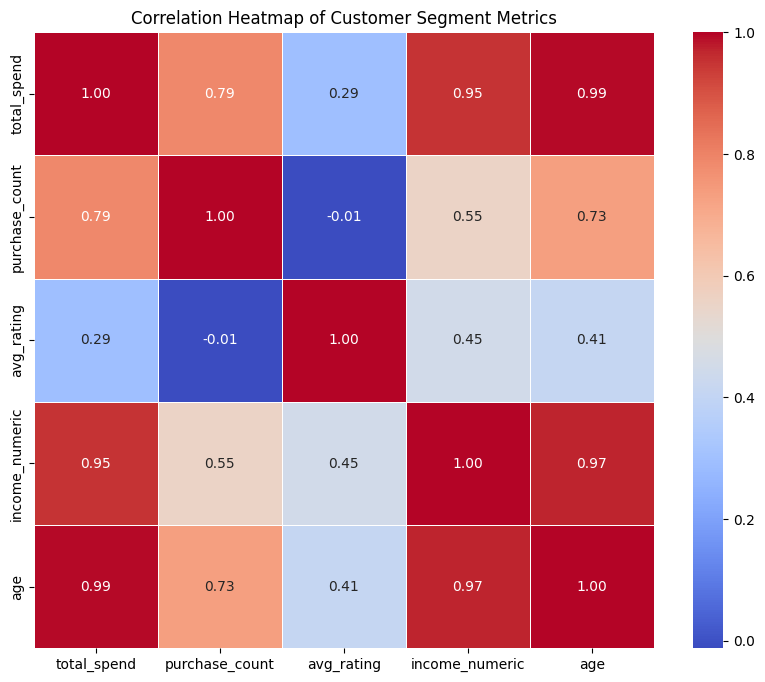

In [14]:
# Merge all summary dataframes
segment_metrics = summary.merge(income_summary, on='cluster')
segment_metrics = segment_metrics.merge(age_summary, on='cluster')

# Drop the 'cluster' column as it's not a metric for correlation
correlation_data = segment_metrics.drop(columns=['cluster'])

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Customer Segment Metrics')
plt.show()

### 9. Top-Rated Product Categories Across Segments
Let's analyze which product categories are most highly rated by users in each customer segment.

In [15]:
# Merge reviews with product categories
reviews_with_category = reviews.merge(products[['product_id', 'category']], on='product_id', how='left')

# Merge with segmentation data
segment_reviews = segment_df[['user_id', 'cluster']].merge(reviews_with_category, on='user_id', how='left')

# Calculate average rating per category per cluster
category_ratings = segment_reviews.groupby(['cluster', 'category'])['rating'].mean().reset_index()

# Find the top-rated category for each cluster
top_categories_per_cluster = category_ratings.loc[category_ratings.groupby('cluster')['rating'].idxmax()]
display(top_categories_per_cluster)

,cluster,category,rating
9,0,Toys & Games,4.636364
11,1,Beauty & Personal Care,5.000000
26,2,Home & Kitchen,4.725275
31,3,Beauty & Personal Care,2.555556


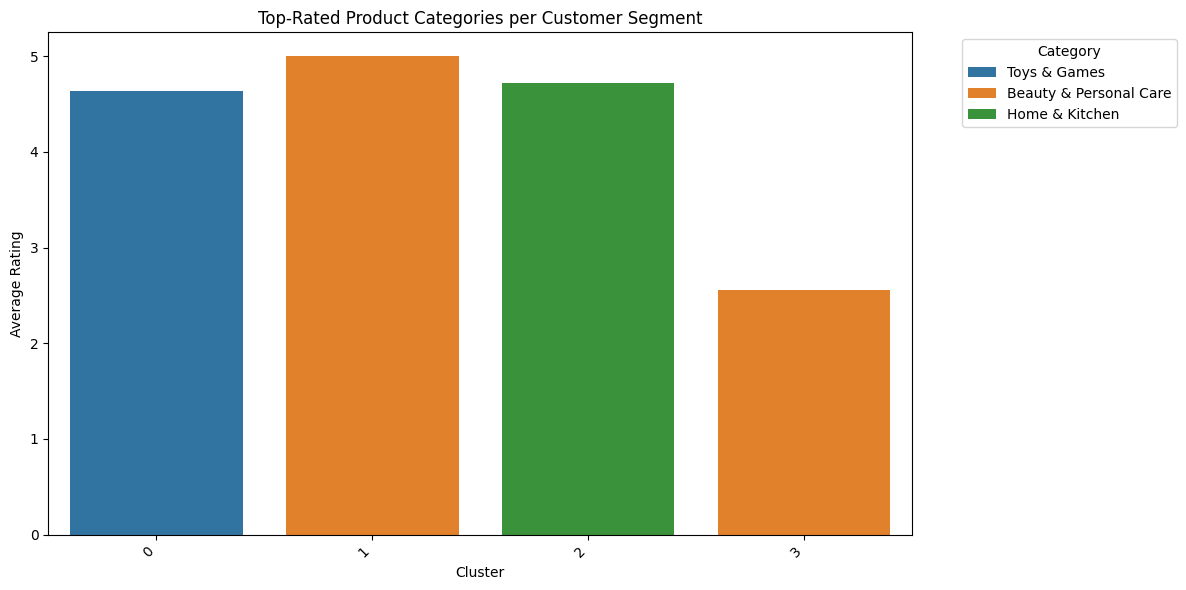

In [16]:
# Visualize top-rated categories per cluster
plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories_per_cluster, x='cluster', y='rating', hue='category', palette='tab10', dodge=False)
plt.title('Top-Rated Product Categories per Customer Segment')
plt.xlabel('Cluster')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 10. Marketing Plan Recommendations per Cluster
Based on the characteristics of each cluster, we can develop targeted marketing strategies.

#### Cluster 0: The Engaged Browsers (or Potential First-Time Buyers)
*   **Characteristics:** Very low spend and purchase count, but moderate average ratings (if they review). Medium income and average age. Top-rated category: Toys & Games.
*   **Recommendations:**
    *   **Focus:** Conversion to first-time buyers, product discovery, engagement.
    *   **Strategy:** Offer attractive first-purchase discounts, free shipping on initial orders, or small introductory bundles. Highlight popular and highly-rated products, especially in 'Toys & Games', through targeted ads and email campaigns. Create engaging content (e.g., gift guides, product tutorials) to encourage browsing and build interest. Utilize retargeting campaigns for abandoned carts.
    *   **Goal:** Convert engagement into transactions and encourage initial spending.

#### Cluster 1: The High-Value Loyalists
*   **Characteristics:** Highest total spend and purchase count, high average ratings. Highest income level and slightly older on average. Top-rated category: Beauty & Personal Care.
*   **Recommendations:**
    *   **Focus:** Retention, loyalty, upselling, cross-selling.
    *   **Strategy:** Implement a premium loyalty program with exclusive perks (e.g., early access to new products, personalized recommendations, dedicated customer support). Offer high-tier products and complementary items, especially within 'Beauty & Personal Care'. Send personalized communications acknowledging their loyalty and suggesting products based on past purchases and preferences. Solicit reviews and testimonials to leverage their high satisfaction.
    *   **Goal:** Maximize customer lifetime value and strengthen brand advocacy.

#### Cluster 2: The Satisfied Regulars
*   **Characteristics:** Moderate spend and purchase count, highest overall average ratings. Medium income and average age. Top-rated category: Home & Kitchen.
*   **Recommendations:**
    *   **Focus:** Increase purchase frequency and average order value, leverage high satisfaction.
    *   **Strategy:** Encourage repeat purchases through subscription options or bundles (e.g., 'Home & Kitchen' essentials subscription). Promote complementary products to increase average order value. Use their high satisfaction in marketing by asking for referrals or encouraging them to share their positive experiences. Send targeted promotions for categories they've shown interest in, particularly 'Home & Kitchen'.
    *   **Goal:** Drive incremental purchases and higher revenue per transaction.

#### Cluster 3: The Dissatisfied Seekers
*   **Characteristics:** Moderate spend and purchase count, but significantly lower average ratings. Medium income and average age. Top-rated category: Beauty & Personal Care (but with low average rating).
*   **Recommendations:**
    *   **Focus:** Address dissatisfaction, improve product experience, regain trust.
    *   **Strategy:** Conduct surveys or direct outreach to understand the root causes of their low ratings. Offer incentives for feedback. Provide improved product recommendations, possibly with a focus on higher-quality items within their preferred 'Beauty & Personal Care' category. Highlight customer service and easy return policies. Consider targeted promotions on new or alternative products to re-engage them with more satisfying options.
    *   **Goal:** Understand and resolve pain points to improve satisfaction and prevent churn.

,cluster,income_numeric
0,0,2.002311
1,1,2.789474
2,2,1.934685
3,3,1.879070


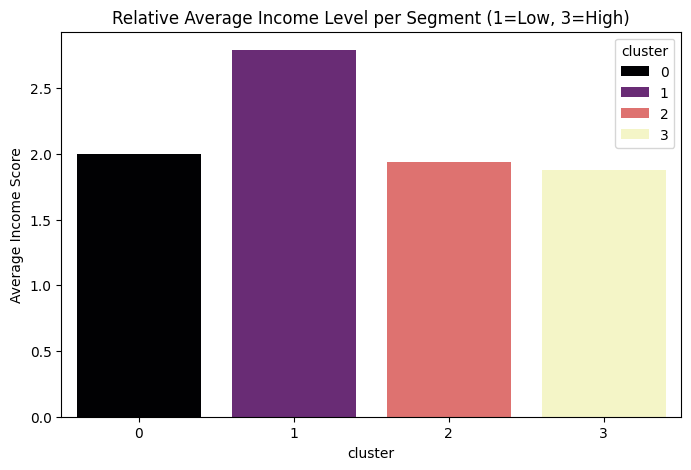

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge income_level from the original users dataframe
if 'income_level' not in segment_df.columns:
    segment_df = segment_df.merge(users[['user_id', 'income_level']], on='user_id', how='left')

# Map categorical income levels to numeric values for comparison
income_map = {'low': 1, 'medium': 2, 'high': 3}
segment_df['income_numeric'] = segment_df['income_level'].map(income_map)

# Calculate average income per cluster
income_summary = segment_df.groupby('cluster')['income_numeric'].mean().reset_index()

# Display and visualize
display(income_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=income_summary, x='cluster', y='income_numeric', hue='cluster', palette='magma')
plt.title('Relative Average Income Level per Segment (1=Low, 3=High)')
plt.ylabel('Average Income Score')
plt.show()

### 11. Exporting Visualizations to PNG
This cell regenerates the key plots and saves them as images in the `/content/` directory for download.

In [18]:
import os

# 1. Save Segmentation Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=segment_df, x='total_spend', y='purchase_count', hue='cluster', palette='viridis')
plt.title('Customer Segments: Spend vs Frequency')
plt.savefig('/content/segmentation_scatter.png')
plt.close()

# 2. Save Income Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=income_summary, x='cluster', y='income_numeric', hue='cluster', palette='magma')
plt.title('Relative Average Income Level per Segment')
plt.savefig('/content/income_distribution.png')
plt.close()

# 3. Save Age Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=age_summary, x='cluster', y='age', hue='cluster', palette='viridis')
plt.title('Average Age per Customer Segment')
plt.savefig('/content/average_age.png')
plt.close()

# 4. Save Age Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=segment_df, x='cluster', y='age', hue='cluster', palette='viridis', legend=False)
plt.title('Age Distribution per Customer Segment')
plt.savefig('/content/age_violin_plot.png')
plt.close()

# 5. Save Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap')
plt.savefig('/content/correlation_heatmap.png')
plt.close()

# 6. Save Top Categories Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories_per_cluster, x='cluster', y='rating', hue='category', palette='tab10', dodge=False)
plt.title('Top-Rated Product Categories')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/top_categories.png')
plt.close()

print("All visualization PNGs have been saved to /content/ directory:")
print(os.listdir('/content/'))

All visualization PNGs have been saved to /content/ directory:
['.config', 'interactions.csv', 'correlation_heatmap.png', 'products.csv', 'top_categories.png', 'reviews.csv', 'users.csv', 'sessions.csv', 'income_distribution.png', 'purchases.csv', 'age_violin_plot.png', 'average_age.png', 'segmentation_scatter.png', 'sample_data']


## Executive Summary: Customer Segmentation Analysis

This analysis aimed to segment our customer base to better understand their behaviors, preferences, and demographics, enabling more targeted marketing strategies. We identified four distinct customer segments based on their total spend, purchase count, and average product ratings.

**Key Findings:**

**Cluster 0:** The Engaged Browsers (or Potential First-Time Buyers)

**Characteristics:** Very low (almost zero) spending and purchase frequency, but moderate product ratings for any reviews given. They have a medium income level and average age.
Insight: These users are engaging with the platform (e.g., browsing, reviewing) but are not yet making significant purchases. Their top-rated category is 'Toys & Games'.

**Cluster 1:** The High-Value Loyalists

**Characteristics:** This is our most valuable segment, demonstrating the highest total spend and purchase frequency, coupled with high average product ratings. They also have the highest average income level and are slightly older.
Insight: These customers are highly satisfied and contribute significantly to revenue. Their top-rated category is 'Beauty & Personal Care'.
Cluster 2: The Satisfied Regulars

**Characteristics:** Moderate spend and purchase frequency, but notably, they exhibit the highest average product ratings across all segments. They have a medium income level and average age.

**Insight:**

These customers are content with their purchases and are good candidates for increasing purchase frequency and average order value. Their top-rated category is 'Home & Kitchen'.

**Cluster 3:** The Dissatisfied Seekers

**Characteristics:**Moderate spend and purchase frequency, but a significantly lower average rating given to products, indicating dissatisfaction. They have a medium income level and average age.
Insight: This segment is experiencing pain points that need to be addressed to prevent churn. Their top-rated category is 'Beauty & Personal Care', but their low ratings within this category are a concern.

**Correlation Insights:**

There's a strong positive correlation between total spend, income level, and age, suggesting that higher-earning and older customers tend to spend more.
Average rating shows weak correlation with other metrics, implying that satisfaction is not directly tied to spending or purchase frequency.

**Marketing Recommendations:**

**For Cluster 0 (Engaged Browsers):** Focus on conversion through first-purchase incentives, targeted product discovery (especially 'Toys & Games'), and retargeting.

**For Cluster 1 (High-Value Loyalists):** Prioritize retention, loyalty, and maximizing customer lifetime value with premium loyalty programs, exclusive offers, and personalized upselling/cross-selling (especially 'Beauty & Personal Care').

**For Cluster 2 (Satisfied Regulars):** Aim to increase purchase frequency and average order value through subscriptions, bundles (particularly 'Home & Kitchen'), and leveraging their high satisfaction for referrals.

**For Cluster 3 (Dissatisfied Seekers):** Implement strategies to address dissatisfaction and regain trust by understanding their pain points through surveys, offering improved recommendations (even within 'Beauty & Personal Care'), and highlighting customer service.

This segmentation provides actionable insights for developing tailored marketing campaigns and product strategies to better serve each customer group and optimize business outcomes.

---
*Analysis by Holarbrain · github.com/holarbrain*
